# Модель для прогнозирования вероятности клика на рекламное объявление

Автор: Кезлинг Владислав

Дата: 08.04.2026.

------------
**Цель:** 
- Разработать модель бинарной классификации, которая предсказывает вероятность клика на рекламное объявление

**Задачи:**
- Провести исследовательский анализ данных, выполнить предобработку с созданием новых признаков и обучить несколько моделей с подбором гиперпараметров, провести калибровку.

**Критерии успешности:**
- Достижение максимально возможного значения метрик: PR_AUC, оценки Бриера.
- Сохранить лучшую и стабильную модель для продакшена.
-----------

# Структура проекта

## 1. Подготовка среды и загрузка данных

#### 1.1 Подготовьте библиотеки
- Создайте файл `requirements.txt` с фиксированными версиями всех пакетов.
- Импортируйте все необходимые библиотеки.
- Настройте параметры отображения графиков и датафреймов.

#### 1.2 Зафиксируйте константу для воспроизводимости
- Установите константу `RANDOM_SEED`.
- Применяйте её ко всем алгоритмам, которые её поддерживают.

#### 1.3 Загрузите данные
- Прочитайте CSV-файл с данными. Путь к файлу: `'/datasets/ds_s16_ad_click_dataset.csv'`
- Выведите размер датасета, первые несколько строк и информацию о типах столбцов.
- Проверьте успешность загрузки данных.

##### 1.1 Подготовка библиотек

In [1]:
# ---------------------------------------------------------
# установка необходимых библиотек (флаг, чтобы не показывались логи)
!pip install -U pandas -q
!pip install -U "scikit-learn>=1.0.2" "numpy>=1.23.5,<1.24" -q
!pip install -U joblib -q
!pip install -U matplotlib -q
!pip install -U seaborn -q
# ---------------------------------------------------------

# ---------------------------------------------------------
# проверка версий для requirements.txt
!pip freeze > requirements.txt
# ---------------------------------------------------------

# ---------------------------------------------------------
# импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import seaborn as sns
import joblib
import os

# skleaern
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.calibration import calibration_curve, CalibrationDisplay, CalibratedClassifierCV
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, f1_score, brier_score_loss
from sklearn.feature_selection import VarianceThreshold, RFE, mutual_info_classif
# ---------------------------------------------------------

import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# настройка отображения графиков
plt.style.use('ggplot')  
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# настройка отображения датафреймов
pd.set_option('display.max_columns', 50)     
pd.set_option('display.max_rows', 100)      
pd.set_option('display.precision', 3)        
pd.set_option('display.float_format', '{:.3f}'.format)
# ---------------------------------------------------------

# ---------------------------------------------------------
# вывод, чтобы удостоверится, что процесс выполнен
print('Выполнено')
# ---------------------------------------------------------

Выполнено


##### 1.2 Фиксация Random_Seed для воспроизводимости

In [2]:
# фиксация
RANDOM_STATE = 42

#####  Загрузка данных

In [3]:
# загружаем и создаём датафрейм
df = pd.read_csv('datasets/ds_s16_ad_click_dataset.csv')

# общая информация
print("Размер датасета:", df.shape)
print("Количество строк:", df.shape[0])
print("Количество столбцов:", df.shape[1])

print("\nНазвания столбцов:")
print(df.columns.tolist(), '\n')

# общая информация
print(df.info())

# первые 5 строк для проверки
df.head()

Размер датасета: (50000, 34)
Количество строк: 50000
Количество столбцов: 34

Названия столбцов:
['id', 'click', 'hour', 'C1', 'banner_pos', 'site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1', 'ml_feature_2', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_7', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10'] 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  obj

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,10052627552648869888.000,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,488a9a3e,31025cda,1,0,17614,320,50,1993,2,1063,-1,33,-0.997,A,0.667,0,0.817,0.993,Z,-0.620,0.434,0.274
1,10105971003478261760.000,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,75bb1b58,2ee63ff8,1,0,15701,320,50,1722,0,35,-1,79,-0.391,C,5.147,1,-0.884,-0.826,X,0.577,-0.319,-0.133
2,10120475683957065728.000,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,285263b0,d780319b,1,0,17914,320,50,2043,2,39,100084,32,-2.113,D,7.169,0,-0.859,-0.338,Y,-0.440,-0.345,0.340
3,1021995395003627776.000,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,0f2161f8,a99f214a,18190986,f4fffcd0,1,0,21611,320,50,2480,3,297,100111,61,0.333,A,-0.291,1,0.063,0.063,Y,0.552,0.733,-0.199
4,10234552355176744960.000,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,b66e5482,a0f5f879,1,0,15702,320,50,1722,0,35,100084,79,1.167,A,6.319,1,-0.675,0.797,X,0.641,0.298,-0.137


-----------
**Промежуточный вывод:**
- Импортированны необходимые библиотеки, зафиксирована константа для воспроизводимости результатов.
- Загружен дадасет и основная информация о нём. 
-----------

## 2. Исследовательский анализ данных (EDA)

#### 2.1 Опишите базовую информацию о датасете
- Определите, сколько объектов и признаков содержится в данных.
- Выясните, какие типы данных представлены (числовые, категориальные).
- Дайте общее описание: укажите, что известно о пользователях и рекламе.

#### 2.2 Анализ целевой переменной
- Проанализируйте, как распределена целевая переменная.
- Определите, есть ли дисбаланс классов. Это важно для выбора метрик.
- Посчитайте долю рекламы, на которую кликнули, и долю рекламы, на которую не кликнули.

#### 2.3 Анализ признаков
- Определите, все ли признаки нужны для обучения модели. Есть ли среди них явно бесполезные?
- Опишите, какие признаки категориальные, а какие — числовые.
- Проведите первичный отбор: удалите ненужные признаки.

#### 2.4 Анализ пропущенных значений
- Проверьте долю пропусков в каждом признаке.
- Выберите корректную стратегию для заполнения пропусков — удаление, среднее, медиана, мода. Выбор обоснуйте.

#### 2.5 Анализ категориальных признаков
- Определите, сколько уникальных значений в каждом категориальном признаке.
- Укажите, какие признаки можно кодировать One-Hot Encoding, а какие требуют специальных методов из-за высокой кардинальности.

#### 2.6 Анализ выбросов и распределений
- Проверьте, есть ли явные выбросы в числовых признаках.
- Опишите, как распределены выбросы — нормально, асимметрично, каким-то другим образом.

#### 2.7 Корреляции
- Определите, какие признаки коррелируют с целевой переменной.
- Выявите сильно скоррелированные признаки, которые можно удалить, если такие есть.

#### 2.8 Выводы по EDA
- Кратко опишите ключевые находки.
- Выберите признаки, которые выглядят наиболее перспективными для модели. Выбор обоснуйте.
- Определите действия по предобработке данных, которые необходимо проделать.

##### 2.1 Описание базовой информации

In [4]:
# описание данных
df.describe().round(2)

,id,click,hour,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21,ml_feature_1,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10
count,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000
mean,9215402302107275264.000,0.170,14102559.040,1004.970,0.290,1.020,0.340,18826.650,318.870,59.690,2109.780,1.430,227.700,53173.380,83.690,-0.000,-0.040,0.500,0.030,0.020,0.030,0.040,0.020
std,5328516395922763776.000,0.380,296.790,1.110,0.510,0.540,0.860,4983.060,20.560,46.720,612.960,1.330,351.590,49960.180,70.540,1.000,5.790,0.500,1.000,0.660,0.580,0.510,0.300
min,31910769195310.000,0.000,14102100.000,1001.000,0.000,0.000,0.000,375.000,120.000,20.000,112.000,0.000,33.000,-1.000,13.000,-4.630,-10.000,0.000,-4.630,-1.000,-1.000,-2.150,-1.290
25%,4580648973216844800.000,0.000,14102304.000,1005.000,0.000,1.000,0.000,16920.000,320.000,50.000,1823.000,0.000,35.000,-1.000,23.000,-0.680,-5.060,0.000,-0.640,-0.580,-0.470,-0.300,-0.180
50%,9243014535888650240.000,0.000,14102602.000,1005.000,0.000,1.000,0.000,20346.000,320.000,50.000,2323.000,2.000,39.000,100049.000,61.000,-0.000,-0.060,0.000,0.030,0.040,0.030,0.040,0.020
75%,13809198391134918656.000,0.000,14102814.000,1005.000,1.000,1.000,0.000,21916.000,320.000,50.000,2526.000,3.000,171.000,100094.000,108.000,0.670,4.990,1.000,0.710,0.640,0.520,0.370,0.220
max,18446516750890600448.000,1.000,14103023.000,1012.000,7.000,5.000,5.000,24043.000,1024.000,1024.000,2757.000,3.000,1839.000,100248.000,255.000,3.790,10.000,1.000,4.230,1.000,1.120,2.120,1.200


-----------
**Информация о датасете:**
- Датасет содержит 34 признака и 50000 объектов.
- В данных представлены как числовые (float64, int64) (например: 'C1'), так и катигориальные (object) признаки (например: 'site_domain').
- Стоит отметить, что в данных есть машинно-сгенерированные признаки (ML Features), они катигориальные и числовые.
- Целевая переменная: 'click'

**Описание пользователей и рекламы:**

**Пользователи**
- В данных есть идентификаторы устройств (device_id), IP-адреса (device_ip) и модели (device_model).
- Технические характеристики: тип устройства (device_type) и тип сетевого соединения (device_conn_type).

**Реклама:**
- Место размещения: известно, где именно показывается реклама — на сайте (site_id, site_domain, site_category) или в мобильном приложении (app_id, app_domain, app_category).
- Характеристики объявления: позиция баннера на странице (banner_pos) и ряд закодированных признаков (C1, C14–C21).
- Время: час показа (hour).

-----------

##### 2.2 Анализ целевой переменной

In [5]:
# распределение целевой переменной (доля кликов)
counts = df['click'].value_counts()
percent = df['click'].value_counts(normalize=True) * 100

print("Количество:")
print(counts)

print("\nПроцентное соотношение:")
print(percent)

Количество:
click
0    41397
1     8603
Name: count, dtype: int64

Процентное соотношение:
click
0   82.794
1   17.206
Name: proportion, dtype: float64


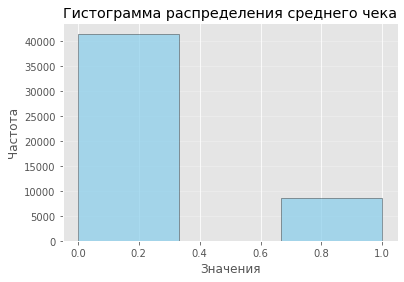

In [6]:
# проверка дизбаланса распределения в целевой переменной
# гистограмма распределения 
plt.hist(df['click'], bins=3, color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Гистограмма распределения среднего чека')
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)

plt.show()

-----------
**Промежуточный вывод:**
- В целевой переменной явный дизбаланс классов (82% на 17%), где 82% пользователей не кликнули на рекламу (значение 0), а 17% кликнули (значение 1).
- Предпочтительные метрики: PR_AUC и precision (так как она не чувствительна к дисбалансу классов).
-----------

##### 2.3 Анализ признаков

In [7]:
# просмотрим ещё раз общую информацию и проверим признаки
# общая информация
print("Размер датасета:", df.shape)

print("\nНазвания столбцов:")
print(df.columns.tolist(), '\n')

# общая информация
print(df.info())

Размер датасета: (50000, 34)

Названия столбцов:
['id', 'click', 'hour', 'C1', 'banner_pos', 'site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1', 'ml_feature_2', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_7', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10'] 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  object 
 6   site_domain       50000 non-null  obje

In [8]:
# удаление признаков и просмотр размеров
cols_to_drop = ['id', 'site_id', 'app_id', 'device_id', 'device_ip']
df_filtred = df.drop(columns=cols_to_drop)

print("Размер датасета:", df_filtred.shape)
print("\nНазвания столбцов:")
print(df_filtred.columns.tolist())

Размер датасета: (50000, 29)

Названия столбцов:
['click', 'hour', 'C1', 'banner_pos', 'site_domain', 'site_category', 'app_domain', 'app_category', 'device_model', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1', 'ml_feature_2', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_7', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10']


In [9]:
# разделение на числовые и категориальные признаки
num_columns = df_filtred.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_columns = df_filtred.select_dtypes(include=['object']).columns.tolist()

print('\nЧисловые признаки:', num_columns)
print('\nКатегориальные признаки:', cat_columns)

print(f"\nКоличество числовых признаков: {len(num_columns)}")
print(f"\nКоличество категориальных признаков: {len(cat_columns)}")


Числовые признаки: ['click', 'hour', 'C1', 'banner_pos', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10']

Категориальные признаки: ['site_domain', 'site_category', 'app_domain', 'app_category', 'device_model', 'ml_feature_2', 'ml_feature_7']

Количество числовых признаков: 22

Количество категориальных признаков: 7


-----------
**Промежуточный вывод:**
- Были удалены явно бесполезные признаки: 'id', 'site_id', 'app_id', 'device_id', 'device_ip', так как они будут создавать шум в данных.
- 'device_ip'имеет 40000+ уникальных значений.


- **Числовые признаки**: 'click'(целевая переменная), 'hour', 'C1', 'banner_pos', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10'. (Количество: 22)


- **Категориальные признаки**: 'site_domain', 'site_category', 'app_domain', 'app_category', 'device_ip', 'device_model', 'ml_feature_2', 'ml_feature_7'. (Количество: 8)
-----------

##### 2.4 Анализ пропущенных значений

In [10]:
#размер до пропусков
print("Размер датасета:", df_filtred.shape)

# ищем пропуски
df_filtred.isnull().sum()

Размер датасета: (50000, 29)


click               0
hour                0
C1                  0
banner_pos          0
site_domain         0
site_category       0
app_domain          0
app_category        0
device_model        0
device_type         0
device_conn_type    0
C14                 0
C15                 0
C16                 0
C17                 0
C18                 0
C19                 0
C20                 0
C21                 0
ml_feature_1        0
ml_feature_2        0
ml_feature_3        0
ml_feature_4        0
ml_feature_5        0
ml_feature_6        0
ml_feature_7        0
ml_feature_8        0
ml_feature_9        0
ml_feature_10       0
dtype: int64

-----------
**Промежуточный вывод:**
- В данных не обнаружено пропущеных значений.

Могу предположить это из-за того, что данный датасет является витринной (результат работы аналитика) и пропуски были обработаны.

-----------

##### 2.5 Анализ категориальных признаков

In [11]:
# смотрим уникальные значения категориальных признаков, чтобы понять как их кодировать
for col in cat_columns:
    print(f"\nПризнак:'{col}': {df_filtred[col].unique()}")
    
print('\n Количество значений:', df_filtred[cat_columns].nunique())


Признак:'site_domain': ['98572c79' 'f3845767' 'c4e18dd6' ... '53175207' '4ebf9b98' '0c34cac9']

Признак:'site_category': ['f028772b' '28905ebd' '50e219e0' '3e814130' '335d28a8' '0569f928'
 '76b2941d' 'a818d37a' '75fa27f6' 'f66779e6' '70fb0e29' '72722551'
 'e787de0e' 'c0dd3be3' 'dedf689d' 'bcf865d9' '8fd0aea4' '42a36e14']

Признак:'app_domain': ['7801e8d9' 'd9b5648e' '2347f47a' 'c6824def' 'b9528b13' '45a51db4'
 'aefc06bd' '5c5a694b' 'ae637522' '82e27996' '813f3323' '0654b444'
 'f2f777fb' 'b5f3b24a' '5b9c592b' '9ec164d3' '885c7f3f' '33da2e74'
 '5c620f04' '6f7ca2ba' 'b8d325c3' 'df32afa9' 'cb36afb8' '828da833'
 '713c0c91' 'bcef5708' '47464e95' '1ed56ded' 'e5d5313f' '1d5e09f4'
 'ad63ec9b' 'd9e67b62' '2619a4f7' '0e8616ad' 'afdf1f54' 'bb6bcbae'
 'b12ff13e' '43cf4f06' 'fc41b20c' '3feeed1e' '863f4950' '18eb4e75'
 '2b627705' '15ec7f39' '27ee373d' 'a8b0bf20' 'db829551' 'd6feb1a4'
 'f435cae0' '2c1c31c6' '47db8711' '7eec2ab0' '3ca588d4' '6a0a3a9d'
 'b9215c20' 'c72257c6' '448ca2e3' 'c5c485e8' '99b4

------------
**Промежуточный вывод:**
- Признаки: 'site_domain', 'site_category', 'app_domain', 'app_category', 'device_model' - необходимо кодировать методом TargetEncoder, так как в них очень много значений, использование жругого метода приведёт к сильному увиличению датасета.
- Признаки: 'ml_feature_2', 'ml_feature_7' - необходимо кодировать методом OneHotEncoder, так как у них мало значений, плюс, данный метод более интерпритируемый.
-------------

##### 2.6 Анализ выбросов и распределений

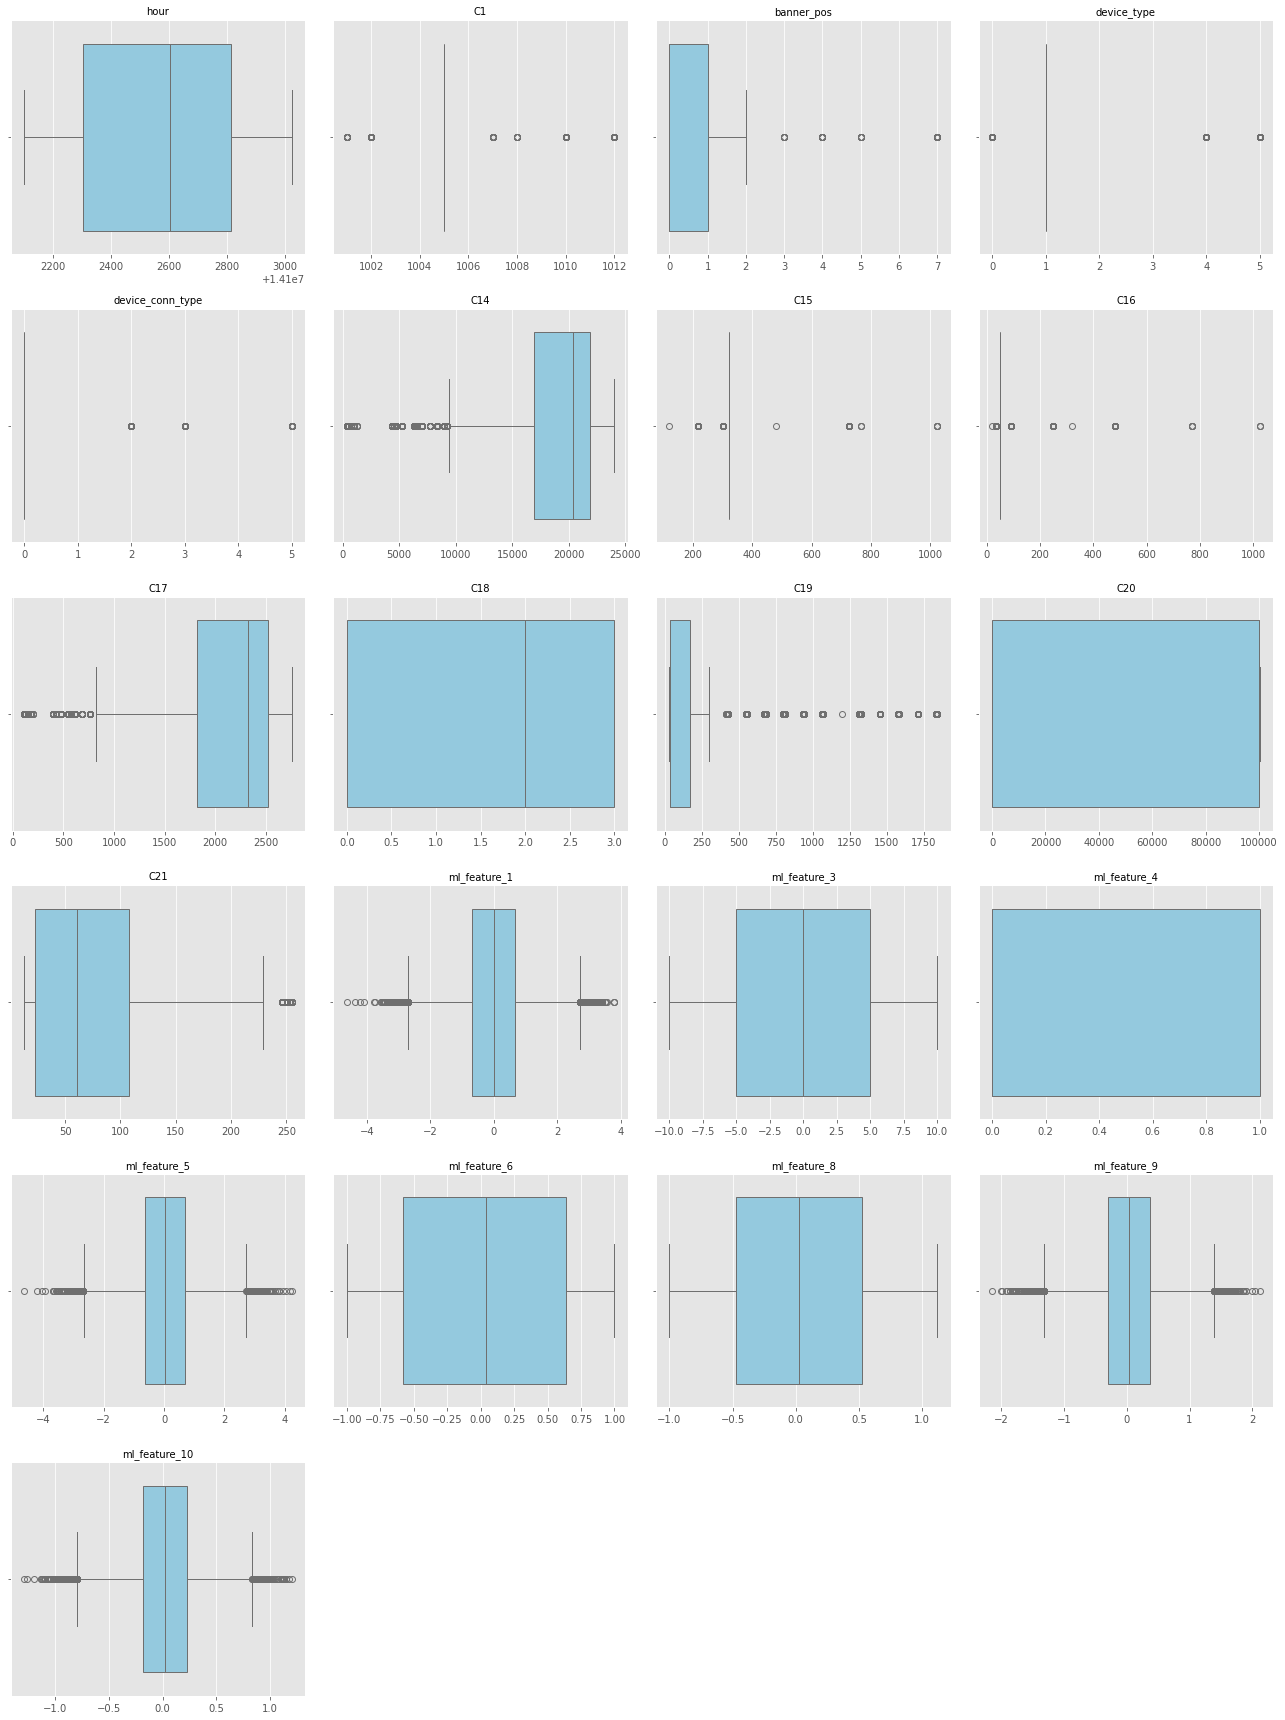

In [12]:
# построим boxplot для просмотра распределения признаков и наличие выбросов
cols_to_plot = [col for col in num_columns if col != 'click']
n_cols = 4
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.boxplot(data=df_filtred, x=col, ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

# Скрываем лишние пустые ячейки (если 20 признаков, а ячеек больше)
for j in range(len(cols_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

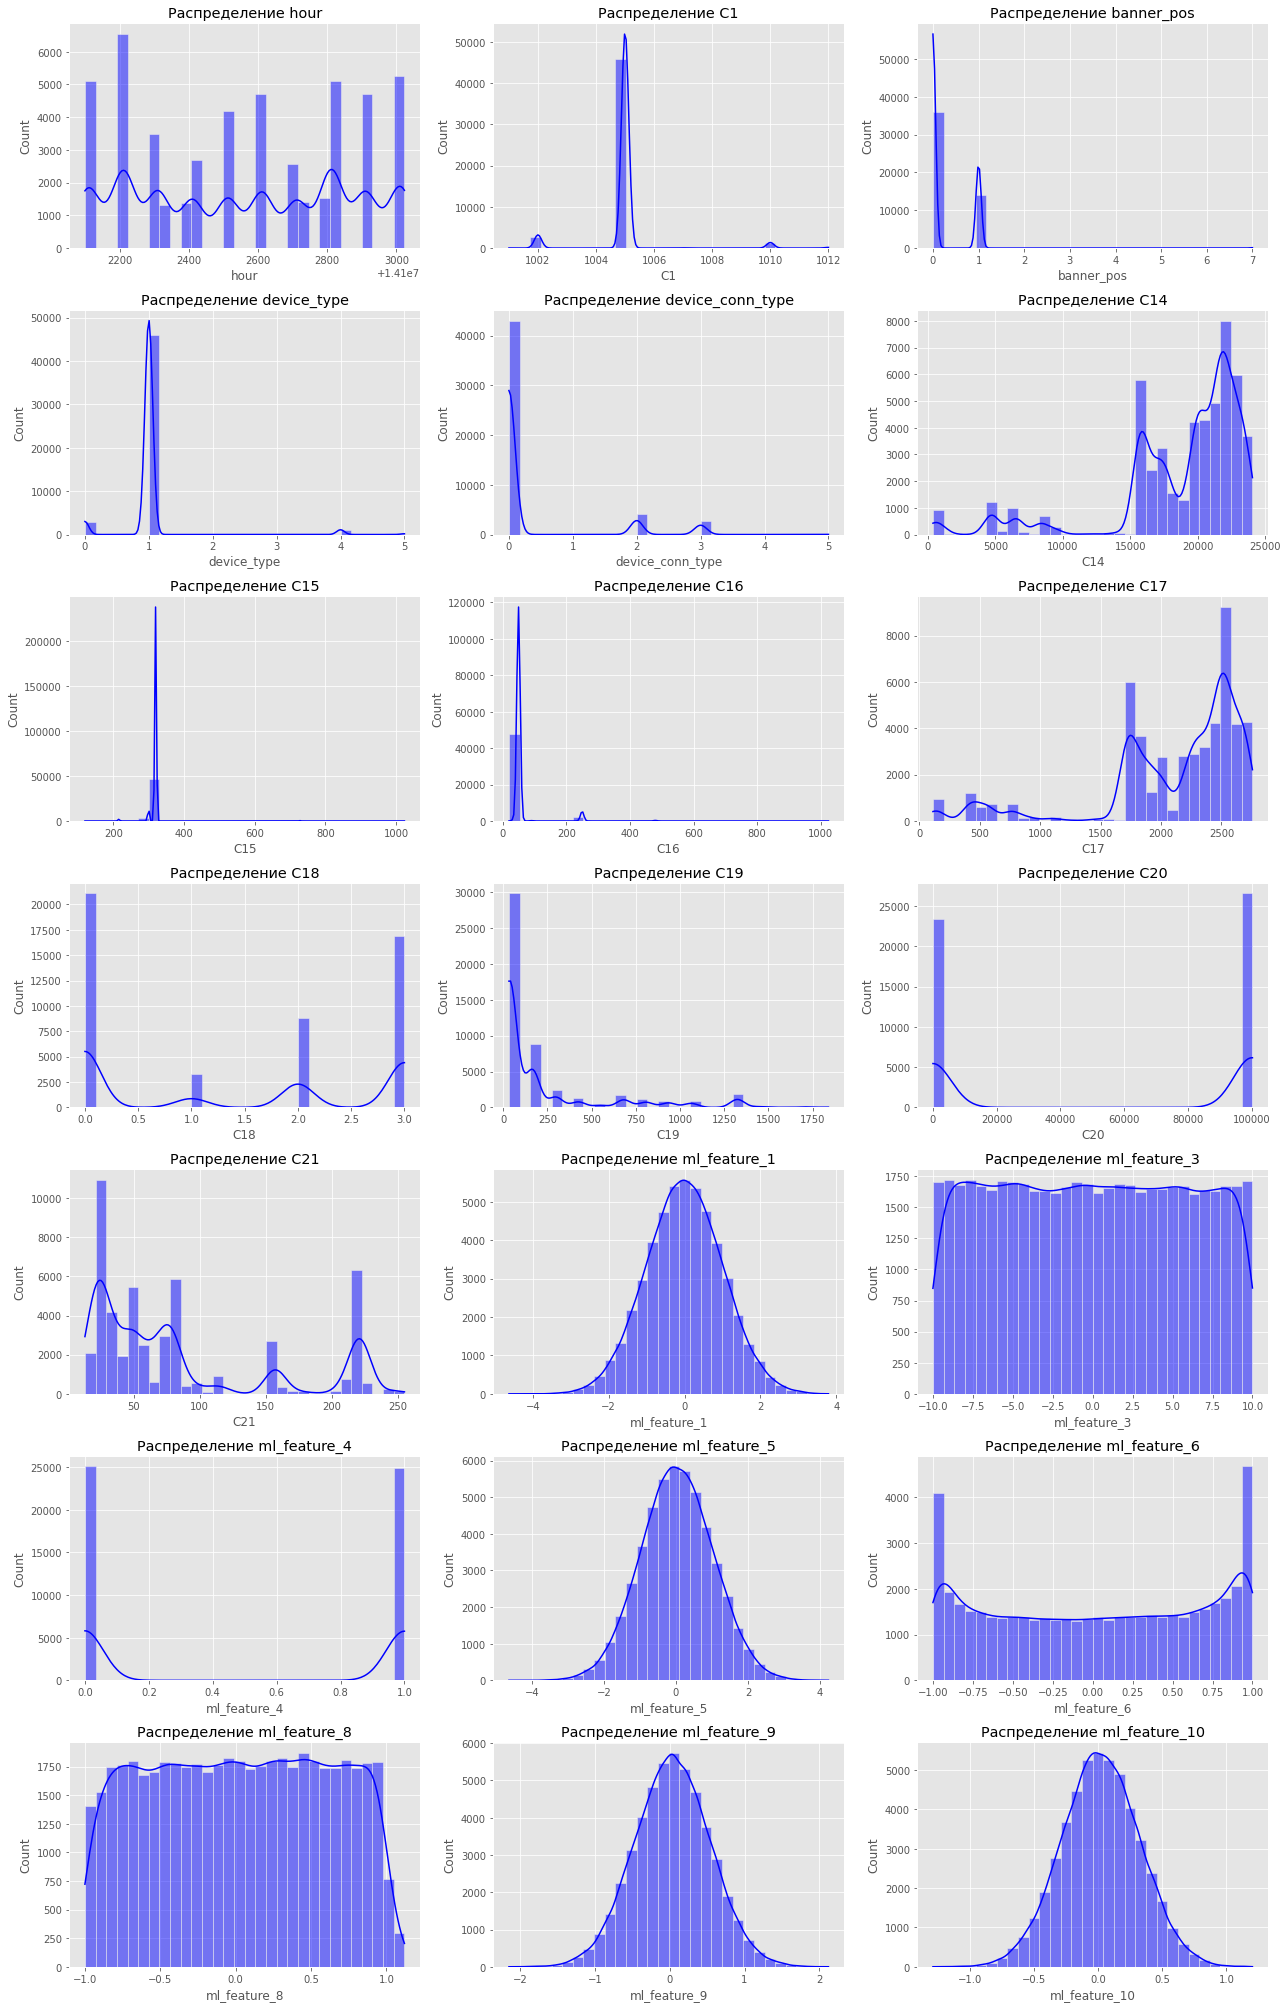

In [13]:
# гистограмма распределения признаков
n_cols = 3
n_rows = math.ceil(len(cols_to_plot) / n_cols)

plt.figure(figsize=(18, n_rows * 4))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df_filtred[col], kde=True, bins=30, color='blue')
    plt.title(f'Распределение {col}')

plt.tight_layout()
plt.show()

--------
**Промежуточный вывод:**
- ml_feature_1, 5, 9, 10: распределены почти нормально. 
- C14, C17: имеют длинные хвосты и выбросы — SVM может быть к ним чувствителен, их необходимо маштабировать.
--------

##### 2.7 Корреляция признаков

In [14]:
# контролирую размер датасета
print("Размер датасета:", df_filtred.shape)

Размер датасета: (50000, 29)


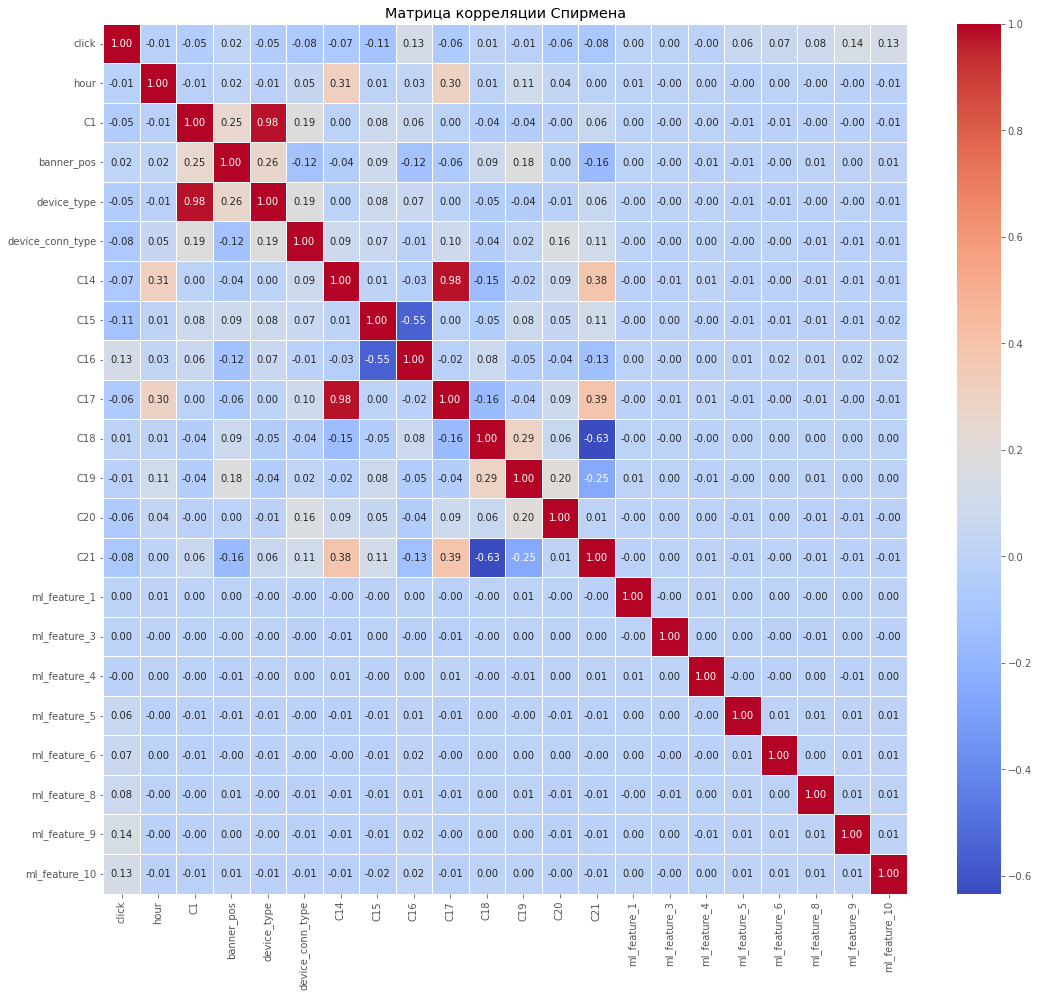

In [15]:
# проверим кореляцию признаков с целевой переменной и между собой
plt.figure(figsize=(18, 16))
sns.heatmap(df_filtred.corr(method='spearman', numeric_only=True), 
            annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляции Спирмена')
plt.show()

In [16]:
# удаление карелирующих признаков
cols_to_drop = ['C1', 'C17']
df_filtred = df_filtred.drop(columns=cols_to_drop)

# ------------------------
# перепроверяем размер (должно уменьшится на 2)
print("Размер датасета:", df_filtred.shape)

Размер датасета: (50000, 27)


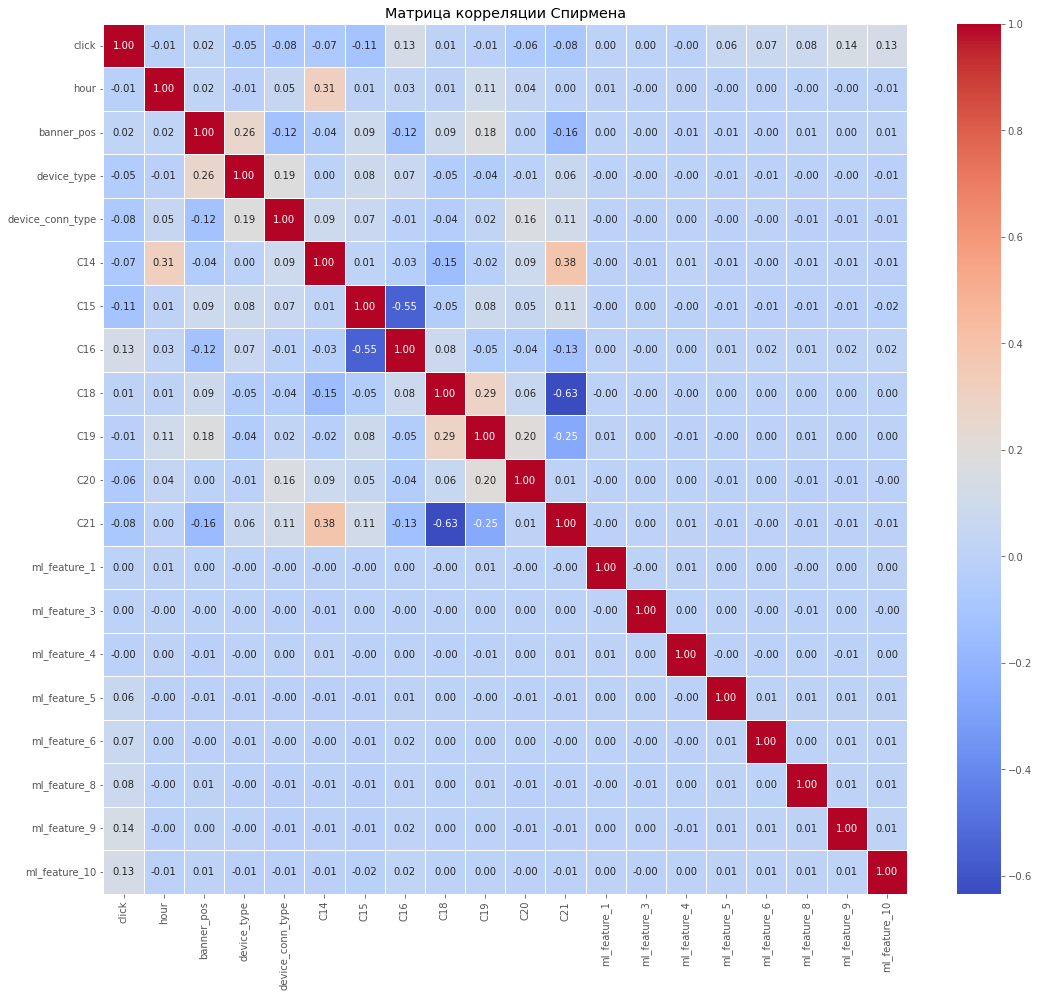

In [17]:
# ещё раз перепроверим
plt.figure(figsize=(18, 16))
sns.heatmap(df_filtred.corr(method='spearman', numeric_only=True), 
            annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляции Спирмена')
plt.show()

------------
**Промежуточный вывод:**
- В данных обнаружены мультикорелирующие признаки: device_type корелирует с C1, C14 корелирует с C17.
- Один признак из каждой пары нужно удалить, иначе веса в будут перетягиваться, а интерпретируемость модели упадет.
- Были удалены признаки из пар, которые меньше корелируют с целевой переменной (С1, С17)
------------

##### Выводы по EDA

----------
**Выводы:**
- В данных дисбаланс классов (17% — клики, 83% — пропуски), поэтому главные метрики: PR-AUC, (потом калибровка с оценкой Биера)
- Пропуски в явном виде отсутствуют, данные предварительно очищены.
- Обнаружена сильная мультиколлинеарность в нескольких парах признаков. Лишние признаки (C1, C17) удалены для стабильности модели.
- Числовые признаки имеют разные масштабы и формы распределений. Присутствуют как нормально распределенные признаки (ml_features), так и признаки с тяжелыми хвостами, их требуется обработать.

**Перспективные признаки:**
- Наиболее перспективными выглядят ml_feature_1 - 10, так как они имеют ненулевую корреляцию с таргетом и хорошое распределение.
- Категориальные признаки site_category и app_category также важны, так как тематика площадки обычно сильно влияет на CTR.

**План предобработки:**
- Применить маштабирование (StandardScaler) ко всем числовым признакам, чтобы признаки с большими значениями не доминировали над остальными.
- OneHotEncoder для признаков с малым числом категорий (ml_feature_2, ml_feature_7).
- TargetEncoder для site_domain, device_model и др.
- После кодирования стоит еще раз проверить корреляцию.
----------

## 3. Разделение данных на выборки

#### 3.1 Разделите данные
- Сначала отделите тестовую выборку, в ней должно быть 20% данных.
- Оставшиеся 80% данных используйте для обучения.
- Используйте стратифицированное разделение, чтобы сохранить баланс классов.
- **Не используйте тестовую выборку до финального тестирования!**

#### 3.2 Проверьте разделение
- Убедитесь, что распределение целевой переменной сохранено в каждой выборке.
- Выведите размеры выборок.

In [18]:
# перепроверяем размер (контроль ситуации)
print("Размер датасета:", df_filtred.shape)

print('\nЧисловые признаки:', num_columns)
print('\nКатегориальные признаки:', cat_columns)

Размер датасета: (50000, 27)

Числовые признаки: ['click', 'hour', 'C1', 'banner_pos', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10']

Категориальные признаки: ['site_domain', 'site_category', 'app_domain', 'app_category', 'device_model', 'ml_feature_2', 'ml_feature_7']


In [19]:
# -----------------------------------------------------------------
# Делим признаки на категориальные, числовые и те, что требуют "особой" обработки

# делим на категориальные признаки
cat_columns = ['site_domain', 'site_category', 'app_domain', 'app_category', 'device_model']

# числовые
num_columns = ['hour', 'banner_pos', 'device_type', 'device_conn_type', 
               'C14', 'C15', 'C16', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1', 
               'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 
               'ml_feature_9', 'ml_feature_10']

# категориальный, но со своей обработкой
spec_columns = ['ml_feature_2', 'ml_feature_7']

# --------------------------

# разделяем признаки и целевую переменную
X = df_filtred.drop(columns=["click"])
y = df_filtred["click"]
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# делаем выборку
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    stratify=y,
    random_state = RANDOM_STATE
)
# -----------------------------------------------------------------

# проверим размеры
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Доля положительного класса в train: {y_train.mean():.3f}")
print(f"Доля положительного класса в test: {y_test.mean():.3f}")

Размер обучающей выборки: (40000, 26)
Размер тестовой выборки: (10000, 26)
Доля положительного класса в train: 0.172
Доля положительного класса в test: 0.172


--------
**Промежуточный вывод:**
- Признаки были разделены на категориальные, числовые и целевую переменную.
- Была произведена выборка на test и train, для обучения и тестирования моделей.
- Размер соотвествует условию (80% на 20%), баланс классов сохранён.
--------

## 4. Предобработка данных — построение пайплайнов

#### 4.1 Создайте пайплайн для предобработки данных

**Для числовых признаков:**
- Корректно заполните пропуски — средним, медианой или другим методом.
- Масштабируйте данные с помощью `StandardScaler`.
- Обработайте выбросы, если необходимо.

**Для категориальных признаков:**
- Корректно заполните пропуски — значением по умолчанию или модой.
- Примените кодирование:
  - One-Hot Encoding для признаков с малой кардинальностью.
  - Target Encoding для признаков с высокой кардинальностью.

#### 4.2 Объедините пайплайны
- Используйте `sklearn.pipeline.Pipeline` и `ColumnTransformer`.
- **Важно:** используйте информацию о пропусках и категориях только из обучающей выборки!

In [20]:
# создадим пайплайны для предобработки (нессмотря на то, что пропусков нет (они уже были обработаны), я сделаю заполнение)

# ----------------------------
# пайплайн для числовых признаков
pipeline_num = Pipeline([
    ('imputer_num', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])
# ----------------------------

# ----------------------------
# пайплайн для категориальных признаков
pipeline_cat = Pipeline([
    ('imputer_cat', SimpleImputer(strategy = 'most_frequent')),
    ('target_encoder', TargetEncoder(random_state = RANDOM_STATE, smooth="auto")) # чтобы не было мульколинеальности (удаляет первый столбец)
])
# ----------------------------

# ----------------------------
# пайплайн для "специальных" признаков
pipeline_spec = Pipeline([
    ('imputer_spec', SimpleImputer(strategy = 'most_frequent')),
    ('one_hot_encoder', OneHotEncoder(drop='first')) 
])
# ----------------------------

# ----------------------------
# строим оптимуса (трансформер)
processor = ColumnTransformer([
    ('num', pipeline_num, num_columns),
    ('cat', pipeline_cat, cat_columns),
    ('spec', pipeline_spec, spec_columns),
])
# ----------------------------

# ----------------------------
# применяем к train, чтобы избежать утечки
X_train_transformed = processor.fit_transform(X_train, y_train)

# названия колонок
feature_names = processor.get_feature_names_out()

# делаем датафреймом для удобстава
X_train_final = pd.DataFrame(X_train_transformed, columns=feature_names)
# ----------------------------

# проверяем размер
print('\n Размер:', X_train_final.shape)

X_train_final.head()


 Размер: (40000, 30)


,num__hour,num__banner_pos,num__device_type,num__device_conn_type,num__C14,num__C15,num__C16,num__C18,num__C19,num__C20,num__C21,num__ml_feature_1,num__ml_feature_3,num__ml_feature_4,num__ml_feature_5,num__ml_feature_6,num__ml_feature_8,num__ml_feature_9,num__ml_feature_10,cat__site_domain,cat__site_category,cat__app_domain,cat__app_category,cat__device_model,spec__ml_feature_2_B,spec__ml_feature_2_C,spec__ml_feature_2_D,spec__ml_feature_2_E,spec__ml_feature_7_Y,spec__ml_feature_7_Z
0,-0.502,-0.564,-0.034,-0.392,0.695,0.053,-0.209,1.188,-0.531,0.939,-0.591,-1.144,-1.146,-0.993,-0.266,-1.013,1.565,2.136,0.646,0.123,0.131,0.084,0.154,0.083,0.000,0.000,0.000,0.000,1.000,0.000
1,-0.169,-0.564,-0.034,-0.392,-0.628,0.053,-0.209,-1.074,-0.548,0.938,-0.066,-0.238,0.102,-0.993,0.941,1.438,0.418,0.148,0.793,0.210,0.210,0.198,0.202,0.147,0.000,1.000,0.000,0.000,0.000,1.000
2,1.501,-0.564,-0.034,1.931,0.870,0.053,-0.209,-1.074,-0.548,-1.066,1.949,1.440,0.869,1.007,0.255,0.142,0.502,0.403,-0.889,0.123,0.131,0.146,0.255,0.191,0.000,1.000,0.000,0.000,0.000,0.000
3,0.532,-0.564,-0.034,-0.392,0.691,0.053,-0.209,1.188,-0.514,0.939,-0.591,0.942,0.808,-0.993,1.145,-1.356,0.398,-1.615,0.293,0.000,0.183,0.198,0.202,0.132,1.000,0.000,0.000,0.000,0.000,0.000
4,1.511,1.359,-0.034,-0.392,0.555,0.053,-0.209,1.188,-0.173,0.937,-0.860,0.121,1.578,1.007,0.154,-1.320,1.477,1.010,2.061,0.217,0.179,0.198,0.202,0.230,0.000,0.000,1.000,0.000,1.000,0.000


-------------
**Промежуточный вывод:**
- Были построены три пайплайна для обработки данных и объеденены в трансформер (позже он будет добавлен в пайплайн с обучением).
- Количество признаков увеличилось с 26 до 30 (+4).
-------------

## 5. Отбор признаков

#### 5.1 Примените фильтрационные методы
- Посчитайте корреляцию каждого признака с целевой переменной.
- Отберите топ лучших признаков. Объясните, почему остановились именно на таком количестве признаков.
- Удалите признаки с очень низкой вариацией `VarianceThreshold`.

#### 5.2 Примените методы-обёртки
- Используйте методы-обёртки для поиска оптимального набора признаков.

#### 5.3 Выберите финальный набор признаков
- Объедините результаты методов.
- Выберите признаки, которые прошли фильтрацию.

##### 5.1 Применение фильтрационных методов

In [21]:
# проверим кореляцию признаков, если есть мультикореируемые или те, 
# что вообще не корелируют с целевой переменной, то необходимо их удалить

# ----------------------------
# Mutual info
mi_scores = mutual_info_classif(X_train_final, 
                                y_train, 
                                random_state=RANDOM_STATE)

# для красивого вывода
mi_results = pd.Series(mi_scores, index=X_train_final.select_dtypes(include=[np.number]).columns)
mi_results = mi_results.sort_values(ascending=False)

print("Топ признаков по корреляции с click:")
print(mi_results.head(20))
# ----------------------------

Топ признаков по корреляции с click:
num__C14                0.037
cat__site_domain        0.030
num__ml_feature_8       0.027
num__C21                0.020
num__C18                0.019
num__C19                0.018
cat__device_model       0.016
num__C20                0.013
num__ml_feature_9       0.012
cat__app_domain         0.011
num__ml_feature_10      0.009
num__C16                0.009
cat__app_category       0.008
cat__site_category      0.007
num__device_conn_type   0.007
num__hour               0.005
num__ml_feature_6       0.005
num__ml_feature_4       0.005
num__C15                0.005
num__banner_pos         0.004
dtype: float64


In [22]:
# размер до
print('\n Размер до:', X_train_final.shape)

# удаление признаков - констант
selector = VarianceThreshold(threshold=0.01) 
X_train_fs = selector.fit_transform(X_train_final)

# названия
selected_columns = X_train_final.columns[selector.get_support()]
X_train_final = pd.DataFrame(X_train_fs, columns=selected_columns)

# размер после
print('\n Размер после:', X_train_final.shape)


 Размер до: (40000, 30)

 Размер после: (40000, 27)


**Мультиколинеальности между признаками не обнаружено, были удалены признаки с низкой вариацией (3 шт) и составлен "топ" признаков из 20шт., так как остальные имеют крайне низкую кореляцию с целевой переменной, также большое количество признаков может привести к переобучению.**

##### 5.2 Применение методов-обёрток

In [23]:
# я буду использовать RFE
rfe_selector = RFE(
    estimator=LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000),
    n_features_to_select=15, # Сколько лучших признаков оставить
    step=1
)

# Обучаем RFE на твоем трансформированном X_train
rfe_selector.fit(X_train_final, y_train)

# Получаем список признаков, которые прошли "отбор"
selected_features_rfe = X_train_final.columns[rfe_selector.support_]

print("Признаки, отобранные методом-оберткой:")
print(selected_features_rfe)

Признаки, отобранные методом-оберткой:
Index(['num__device_type', 'num__device_conn_type', 'num__C14', 'num__C20',
       'num__ml_feature_5', 'num__ml_feature_6', 'num__ml_feature_8',
       'num__ml_feature_9', 'num__ml_feature_10', 'cat__site_domain',
       'cat__device_model', 'spec__ml_feature_2_B', 'spec__ml_feature_2_C',
       'spec__ml_feature_7_Y', 'spec__ml_feature_7_Z'],
      dtype='object')


**RFE выбрал некоторые признаки (например, num__C14 или cat__device_model), которых не было в самом топе по корреляции Пирсона. Метод-обёртка улавливает взаимосвязи между признаками, которые простая корреляция не видит.**

##### 5.3 Выбор финального набора признаков

In [24]:
# финальный список признаков
final_features = selected_features_rfe.tolist()
X_train_ready = X_train_final[final_features]

# итоговый размер
print("Финальный размер обучающей выборки:", X_train_ready.shape)
print("\nФинальный набор признаков для обучения моделей:")
for col in final_features:
    print(f"- {col}")
    
X_train_ready.head()

Финальный размер обучающей выборки: (40000, 15)

Финальный набор признаков для обучения моделей:
- num__device_type
- num__device_conn_type
- num__C14
- num__C20
- num__ml_feature_5
- num__ml_feature_6
- num__ml_feature_8
- num__ml_feature_9
- num__ml_feature_10
- cat__site_domain
- cat__device_model
- spec__ml_feature_2_B
- spec__ml_feature_2_C
- spec__ml_feature_7_Y
- spec__ml_feature_7_Z


,num__device_type,num__device_conn_type,num__C14,num__C20,num__ml_feature_5,num__ml_feature_6,num__ml_feature_8,num__ml_feature_9,num__ml_feature_10,cat__site_domain,cat__device_model,spec__ml_feature_2_B,spec__ml_feature_2_C,spec__ml_feature_7_Y,spec__ml_feature_7_Z
0,-0.034,-0.392,0.695,0.939,-0.266,-1.013,1.565,2.136,0.646,0.123,0.083,0.000,0.000,1.000,0.000
1,-0.034,-0.392,-0.628,0.938,0.941,1.438,0.418,0.148,0.793,0.210,0.147,0.000,1.000,0.000,1.000
2,-0.034,1.931,0.870,-1.066,0.255,0.142,0.502,0.403,-0.889,0.123,0.191,0.000,1.000,0.000,0.000
3,-0.034,-0.392,0.691,0.939,1.145,-1.356,0.398,-1.615,0.293,0.000,0.132,1.000,0.000,0.000,0.000
4,-0.034,-0.392,0.555,0.937,0.154,-1.320,1.477,1.010,2.061,0.217,0.230,0.000,0.000,1.000,0.000


-------
**Промежуточный вывод:**
- Для финального обучения моделей был сформирован набор из 15 признаков.
- Сначала данные прошли фильтрацию методом VarianceThreshold, который удалил константные признаки (шум), затем был применен метод-обёртка RFE.
- Итоговый выбор в пользу RFE, так как он оценивает не просто кореляцию, а то, как признаки работают совместно в рамках предсказательной модели. Учитываются главные признаки, и это служит защитой от переобучения (убраны 12 признаков).
-------

## 6. Обучение базовой модели

### 6.1 Обучите `DummyClassifier`
- Это нужно, чтобы обозначить самый простой базовый уровень работы модели.

### 6.2 Обучите `LogisticRegression`
- Используйте для обучения отобранные признаки.
- Примените кросс-валидацию на 5 фолдах.
- Посчитайте метрику PR-AUC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Напоминаем, что для корректной кросс-валидации, предобработку нужно объединить с классификатором в Pipeline.

### 6.3 Обучите `SVC`

- Обучите SVC линейным ядром.
- Примените кросс-валидацию на 5 фолдах и посчитайте ту же метрику PR-ROC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Калибровку модели мы проведём далее, поэтому здесь нужна модель `probability=False`

### 6.4 Сравните модели
- Убедитесь, что `LogisticRegression` работает лучше `DummyClassifier`.
- Сравните качество `LogisticRegression` с `SVC`.

##### 6.1-6.3 Обучение моделей

In [25]:
# список новых признаков
final_num_cols = ['device_type', 'device_conn_type', 'C14', 'C20', 
                  'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 
                  'ml_feature_9', 'ml_feature_10']

final_cat_cols = ['site_domain', 'device_model']

final_spec_cols = ['ml_feature_2', 'ml_feature_7']

# просессор
final_processor = ColumnTransformer([
    ('num', pipeline_num, final_num_cols),
    ('cat', pipeline_cat, final_cat_cols),
    ('spec', pipeline_spec, final_spec_cols),
])

# финальный X
X_train_final_input = X_train[final_num_cols + final_cat_cols + final_spec_cols]

print('Размер:', len(X_train_final_input))

Размер: 40000


In [26]:
# ----------------------------
# дамми модель 
full_pipeline_dummy = Pipeline(steps=[
    ('preprocessor', final_processor),
    ('classifier_dum', DummyClassifier(strategy="most_frequent"))
])
# настройка кросс-валидации
cv_dum = StratifiedKFold(n_splits = 5, shuffle = True, random_state = RANDOM_STATE)
results_dummy = cross_validate(
    estimator=full_pipeline_dummy,              
    X=X_train_final_input, y=y_train,                                   
    scoring=['average_precision', 'f1', 'precision', 'recall'],  
    cv=cv_dum, 
    n_jobs=-1
)
# ----------------------------

# ----------------------------
# логрег модель
full_pipeline_log = Pipeline([
    ('preprocessor', final_processor), 
    ('classifier_log', LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced')) 
])

# настройка кросс-валидации
cv_log = StratifiedKFold(n_splits = 5, shuffle = True, random_state = RANDOM_STATE)
results_base_log = cross_validate(
    estimator=full_pipeline_log,              
    X=X_train_final_input,                                  
    y=y_train,                                   
    scoring=['average_precision', 'f1', 'precision', 'recall'],  
    cv=cv_log,                                                
    n_jobs=-1                              
)
# ----------------------------

# ----------------------------
# svm модель
full_pipeline_svm = Pipeline([
    ('preprocessor', final_processor), 
    ('classifier_svm', SVC(random_state=RANDOM_STATE, kernel='linear', probability=False, class_weight='balanced')) 
])

# настройка кросс-валидации
cv_svm = StratifiedKFold(n_splits = 5, shuffle = True, random_state = RANDOM_STATE)
results_base_svc = cross_validate(
    estimator=full_pipeline_svm,              
    X=X_train_final_input,                                  
    y=y_train,                                   
    scoring=['average_precision', 'f1', 'precision', 'recall'],  
    cv=cv_svm,                                               
    n_jobs=-1                              
)
# ----------------------------

**Модели обучены, сравниваем метрики.**

##### 6.4 Сравнение моделей

In [27]:
# Выводим метрики 
def print_metrics(name, results):
    print(f"--- Метрики для модели: {name} ---")
    print(f"PR-AUC (Average Precision) на фолдах: {np.round(results['test_average_precision'], 3)}")
    print(f"PR-AUC Mean: {np.mean(results['test_average_precision']).round(3)}")
    print(f"F1-score Mean: {np.mean(results['test_f1']).round(3)}")
    print(f"Precision Mean: {np.mean(results['test_precision']).round(3)}")
    print(f"Recall Mean: {np.mean(results['test_recall']).round(3)}")
    print("-" * 40)

print_metrics("Dummy Classifier", results_dummy)
print_metrics("Logistic Regression", results_base_log)
print_metrics("SVC (Linear Kernel)", results_base_svc)

--- Метрики для модели: Dummy Classifier ---
PR-AUC (Average Precision) на фолдах: [0.172 0.172 0.172 0.172 0.172]
PR-AUC Mean: 0.172
F1-score Mean: 0.0
Precision Mean: 0.0
Recall Mean: 0.0
----------------------------------------
--- Метрики для модели: Logistic Regression ---
PR-AUC (Average Precision) на фолдах: [0.376 0.385 0.393 0.4   0.39 ]
PR-AUC Mean: 0.389
F1-score Mean: 0.417
Precision Mean: 0.304
Recall Mean: 0.662
----------------------------------------
--- Метрики для модели: SVC (Linear Kernel) ---
PR-AUC (Average Precision) на фолдах: [0.374 0.384 0.393 0.399 0.389]
PR-AUC Mean: 0.388
F1-score Mean: 0.417
Precision Mean: 0.305
Recall Mean: 0.66
----------------------------------------


--------
**Промежуточный вывод:**
- Обе обученные модели показали результат значительно выше базового уровня (DummyClassifier), где PR-AUC составляет 0.172. Это подтверждает эффективность отобранных признаков.
- Использование параметра class_weight='balanced' позволило добиться высокого показателя полноты (Recall 0.66). Модели успешно идентифицируют около 66% потенциальных кликов, что критически важно в условиях сильного дисбаланса классов (кликов всего 17%).


**Выбор лучшей модели:**
- Logistic Regression (PR-AUC = 0.389) и SVC (PR-AUC = 0.388) продемонстрировали практически идентичное качество.Однако Logistic Regression работает существенно быстрее и менее требовательна к вычислительным ресурсам. Кроме того, она позволяет получать вероятности напрямую, что упростит калибровку.
--------

## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией

#### 7.1 Определите сетку гиперпараметров
Определите ключевые параметры, которые влияют на качество моделей `LogisticRegression` и `SVC`.

#### 7.2 Примените Grid Search
- Используйте `GridSearchCV` для перебора всех комбинаций.
- Используйте `scoring='average_precision'`.
- Выведите лучшие параметры и их метрики.

#### 7.3 Составьте таблицу результатов
- Покажите топ-10 конфигураций с их метриками.

In [28]:
# Подбор гиперпараметров
# --------------------------------------------------
cv_gs = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
# --------------------------------------------------

# LogReg

param_grid_log = {
    'classifier_log__C': [0.01, 0.1, 1, 10, 100],
    'classifier_log__penalty': ['l1', 'l2'],
    'classifier_log__solver': ['liblinear']
}

# GridSearchCV
grid_log = GridSearchCV(
    estimator= full_pipeline_log,             
    param_grid= param_grid_log,             
    cv= cv_gs,            
    scoring='average_precision',        
    n_jobs= -1,        
    verbose= 1       
)

# Запуск поиска
grid_log.fit(X_train_final_input, y_train)

# Сохраним лучшую комбинацию гиперпараметров в отдельную переменную
best_params_log = grid_log.best_params_

# Сохраним лучшую модель в отдельную переменную
best_estimator_log = grid_log.best_estimator_

# Сохраним лучший результат accuracy в отдельную переменную
best_score_log= round(grid_log.best_score_, 3)

# Вывод лучших гиперпараметров, модели и результата
print("Лучшие гиперпараметры:", best_params_log)
print("Лучшая модель:", best_estimator_log)
print("Лучший PR-AUC:", best_score_log)
# --------------------------------------------------



# --------------------------------------------------
# я исключил poly и sigmoid, так как чаще всего они не дадут прироста относительно rbf или linear, а обучение уже идёт 20минут
# SVM
# Сетки гиперпараметров с учётом специфики ядер
param_grid_svm = [
    # Линейное ядро: только C
    {
        "classifier_svm__kernel": ["linear"],
        "classifier_svm__C": [0.1, 1, 10]  
    },

    # RBF: только C и gamma
    {
        "classifier_svm__kernel": ["rbf"],
        "classifier_svm__C": [0.1, 1, 10],
        "classifier_svm__gamma": ["scale", "auto"]
    },

] 

# GridSearchCV
grid_svm = GridSearchCV(
    estimator= full_pipeline_svm,             
    param_grid= param_grid_svm,             
    cv= cv_gs,            
    scoring='average_precision',        
    n_jobs= -1,        
    verbose= 1       
)

# Запуск поиска
grid_svm.fit(X_train_final_input, y_train)

# Сохраним лучшую комбинацию гиперпараметров в отдельную переменную
best_params_svm = grid_svm.best_params_

# Сохраним лучшую модель в отдельную переменную
best_estimator_svm = grid_svm.best_estimator_

# Сохраним лучший результат accuracy в отдельную переменную
best_score_svm = round(grid_svm.best_score_, 3)

# Вывод лучших гиперпараметров, модели и результата
print("Лучшие гиперпараметры:", best_params_svm)
print("Лучшая модель:", best_estimator_svm)
print("Лучший PR-AUC:", best_score_svm)
# --------------------------------------------------

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Лучшие гиперпараметры: {'classifier_log__C': 0.1, 'classifier_log__penalty': 'l1', 'classifier_log__solver': 'liblinear'}
Лучшая модель: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer_num',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['device_type',
                                                   'device_conn_type', 'C14',
                                                   'C20', 'ml_feature_5',
                                                   'ml_feature_6',
                                                   'ml_feature_8',
           

In [29]:
# Таблица для logreg
log_results = pd.DataFrame(grid_log.cv_results_).sort_values('rank_test_score')
print("Топ-10 конфигураций Logistic Regression:")
display(log_results[['params', 'mean_test_score', 'rank_test_score']].head(10))

# Таблица для SVM
svm_results = pd.DataFrame(grid_svm.cv_results_).sort_values('rank_test_score')
print("\nТоп-10 конфигураций SVM:")
display(svm_results[['params', 'mean_test_score', 'rank_test_score']].head(10))

Топ-10 конфигураций Logistic Regression:


,params,mean_test_score,rank_test_score
2,"{'classifier_log__C': 0.1, 'classifier_log__pe...",0.390,1
5,"{'classifier_log__C': 1, 'classifier_log__pena...",0.389,2
4,"{'classifier_log__C': 1, 'classifier_log__pena...",0.389,3
7,"{'classifier_log__C': 10, 'classifier_log__pen...",0.389,4
6,"{'classifier_log__C': 10, 'classifier_log__pen...",0.389,5
8,"{'classifier_log__C': 100, 'classifier_log__pe...",0.389,6
9,"{'classifier_log__C': 100, 'classifier_log__pe...",0.389,7
3,"{'classifier_log__C': 0.1, 'classifier_log__pe...",0.389,8
0,"{'classifier_log__C': 0.01, 'classifier_log__p...",0.384,9
1,"{'classifier_log__C': 0.01, 'classifier_log__p...",0.372,10



Топ-10 конфигураций SVM:


,params,mean_test_score,rank_test_score
1,"{'classifier_svm__C': 1, 'classifier_svm__kern...",0.389,1
2,"{'classifier_svm__C': 10, 'classifier_svm__ker...",0.389,2
0,"{'classifier_svm__C': 0.1, 'classifier_svm__ke...",0.389,3
6,"{'classifier_svm__C': 1, 'classifier_svm__gamm...",0.384,4
5,"{'classifier_svm__C': 1, 'classifier_svm__gamm...",0.376,5
8,"{'classifier_svm__C': 10, 'classifier_svm__gam...",0.374,6
4,"{'classifier_svm__C': 0.1, 'classifier_svm__ga...",0.361,7
3,"{'classifier_svm__C': 0.1, 'classifier_svm__ga...",0.358,8
7,"{'classifier_svm__C': 10, 'classifier_svm__gam...",0.351,9


----------
**Промежуточный вывод:**
- В результате Grid Search обе модели — Logistic Regression и SVC — показали идентичное качество по метрике PR-AUC (0.388).
- -Logistic Regression оптимальными стали параметры C=0.1 и penalty='l1'. L1-регуляризация эффективно отсеивает шум в признаках, что критично для данных с большим количеством категорий.
- SVC лучшим оказалось линейное ядро (kernel='linear'). Попытки использовать нелинейное ядро RBF привели к снижению качества (до 0.35).

**Выбор:** 
- Несмотря на равенство метрик, для финального обучения выбрана Logistic Regression. Она обучается и делает предсказания в десятки раз быстрее (SVM обучался около 30 минут), а также позволяет легко интерпретировать веса признаков и получать вероятности без дополнительных вычислительных затрат.
----------

## 8. Финальная модель

#### 8.1 Обучите финальную модель
- Используйте лучшие параметры из Grid Search.
- Обучите модели на всей обучающей выборке.

#### 8.2 Посчитайте метрики на тестовой выборке
- Необходимые метрики:
  - PR-AUC.
  - Оценка Бриера.
  - Дополнительные метрики при необходимости.

#### 8.3 Проанализируйте веса модели
- Выведите самые важные признаки по модулю коэффициентов.
- Интерпретируйте результаты.

In [30]:
# --------------------------------------------------
# Обучение лучше модели и подсчет метрик
final_model = grid_log.best_estimator_
final_model.fit(X_train_final_input, y_train)
# --------------------------------------------------


# --------------------------------------------------
# Подготовка тестовых данных 
X_test_final = X_test[final_num_cols + final_cat_cols + final_spec_cols]

# Получаем вероятности 
probs = final_model.predict_proba(X_test_final)[:, 1]

# 1. PR-AUC
test_pr_auc = average_precision_score(y_test, probs)

# 2. Оценка Бриера 
test_brier = brier_score_loss(y_test, probs)

print(f"Финальный PR-AUC на тесте: {test_pr_auc:.3f}")
print(f"Оценка Бриера на тесте: {test_brier:.3f}")
# --------------------------------------------------

Финальный PR-AUC на тесте: 0.379
Оценка Бриера на тесте: 0.207


In [31]:
# название признаков
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()

# coeff
coeffs = final_model.named_steps['classifier_log'].coef_[0]

# Собираем в таблицу
importance_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coeffs,
    'abs_coef': np.abs(coeffs)
}).sort_values(by='abs_coef', ascending=False)

print("Топ-10 наиболее влиятельных признаков:")
display(importance_df.head(10))

Топ-10 наиболее влиятельных признаков:


,feature,coef,abs_coef
9,cat__site_domain,4.889,4.889
10,cat__device_model,1.520,1.520
7,num__ml_feature_9,0.408,0.408
8,num__ml_feature_10,0.345,0.345
16,spec__ml_feature_7_Z,-0.205,0.205
6,num__ml_feature_8,0.201,0.201
4,num__ml_feature_5,0.169,0.169
5,num__ml_feature_6,0.164,0.164
1,num__device_conn_type,-0.137,0.137
2,num__C14,-0.127,0.127


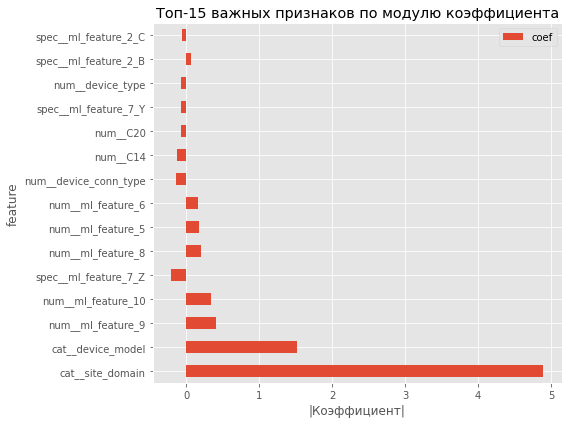

In [32]:
importance_df.head(15).plot(x='feature', y='coef', kind='barh', figsize=(8, 6))
plt.title('Топ-15 важных признаков по модулю коэффициента')
plt.xlabel('|Коэффициент|')
plt.tight_layout()
plt.show()

-----------
**Промежуточный вывод:**

- Финальная модель на тестовой выборке показала PR-AUC = 0.379. Это стабильный результат (отклонение от кросс-валидации менее 3%).
- Оценка Бриера (0.207) указывает на хорошую калибровку вероятностей. Учитывая, что средний CTR в данных около 17%, такая ошибка говорит о том, что предсказания модели можно использовать для оценки реальной вероятности клика.

**Признаки:**
- Самыми важными факторами оказались site_domain (coef: 4.89) и device_model (coef: 1.52). Площадка размещения и модель устройства пользователя являются определяющими в мобильной рекламе.

- Анонимные признаки ml_feature_9 и ml_feature_10 также вошли в топ, что оправдывает их включение в финальный набор признаков.

- Отрицательные веса: Признаки ml_feature_7_Z, device_conn_type и C14 имеют отрицательные коэффициенты. Это означает, что их наличие или рост значений снижает вероятность клика.
-----------

## 9. Калибровка модели

#### 9.1 Проверьте текущую калибровку
- Постройте калибровочную кривую, используйте `sklearn.calibration.calibration_curve`.
- Для обработки «сырых» значений SVC, нужно применить стандартную (необученную) сигмоиду для получения [0, 1].

#### 9.2 Примените методы калибровки
- Используйте `CalibratedClassifierCV` с методом `'isotonic'`.
- **Важно:** используйте для процедуры отдельную калибровочную выборку!

#### 9.3 Сравните модели до и после калибровки
- Посчитайте оценки Бриера для моделей до и после калибровки.
- Дополнительно можете рассчитать ECE и MCE для моделей до и после калибровки.
- Визуализируйте калибровочные кривые для моделей до и после калибровки.

Brier Score до калибровки: 0.2064
Brier Score после калибровки: 0.1269


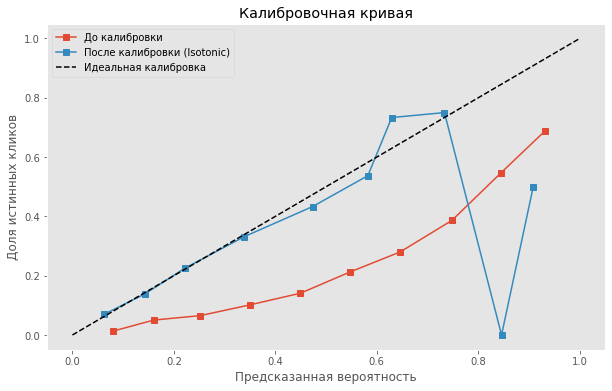

In [33]:
# калибровочная выборка
X_sub_train, X_calib, y_sub_train, y_calib = train_test_split(
    X_train_final_input, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
)

# обучение
base_model = grid_log.best_estimator_
base_model.fit(X_sub_train, y_sub_train)

# получение вероятности
probs_uncalibrated = base_model.predict_proba(X_test_final)[:, 1]

# применяем калибровку
calibrator = CalibratedClassifierCV(base_model, cv='prefit', method='isotonic')
calibrator.fit(X_calib, y_calib)

# вероятность на тесте
probs_calibrated = calibrator.predict_proba(X_test_final)[:, 1]

# метрика
brier_before = brier_score_loss(y_test, probs_uncalibrated)
brier_after = brier_score_loss(y_test, probs_calibrated)

print(f"Brier Score до калибровки: {brier_before:.4f}")
print(f"Brier Score после калибровки: {brier_after:.4f}")

# ввизуализация
fraction_of_positives_uncal, mean_predicted_value_uncal = calibration_curve(y_test, probs_uncalibrated, n_bins=10)
fraction_of_positives_cal, mean_predicted_value_cal = calibration_curve(y_test, probs_calibrated, n_bins=10)

plt.figure(figsize=(10, 6))
plt.plot(mean_predicted_value_uncal, fraction_of_positives_uncal, "s-", label="До калибровки")
plt.plot(mean_predicted_value_cal, fraction_of_positives_cal, "s-", label="После калибровки (Isotonic)")
plt.plot([0, 1], [0, 1], "k--", label="Идеальная калибровка")
plt.ylabel("Доля истинных кликов")
plt.xlabel("Предсказанная вероятность")
plt.title("Калибровочная кривая")
plt.legend()
plt.grid()
plt.show()

-------
**Промежуточный вывод:**
- Проведена калибровка предсказаний модели с использованием метода Isotonic. Это было необходимо, так как базовая модель завышала вероятности клика.
- Удалось снизить Brier Score с 0.206 до 0.127, что делает вероятности модели пригодными для использования.
- Калибровочная кривая после обработки по началу практичесик совпадает с идеальной диагональю.
--------

## 10. Оценка качества калибровки

#### 10.1 Посчитайте метрики калибровки
- Оценка Бриера — средняя ошибка предсказанной вероятности.
- Дополнительная метрика ECE: среднее расхождение вероятностей.
- Дополнительная метрика MCE: максимальное расхождение вероятностей.

#### 10.2 Сравните модели до и после калибровки
- Выведите все метрики в одной таблице.
- Сделайте вывод о том, улучшила ли калибровка качество моделей.

In [34]:
# --------------------------------------------------
def calculate_ece_mce(y_true, y_probs, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    ece = 0
    mce = 0
    
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (y_probs > bin_lower) & (y_probs <= bin_upper)
        prop_in_bin = np.mean(in_bin)
        
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(y_true[in_bin])
            avg_confidence_in_bin = np.mean(y_probs[in_bin])
            delta = np.abs(avg_confidence_in_bin - accuracy_in_bin)
            
            ece += delta * prop_in_bin
            mce = max(mce, delta)
            
    return ece, mce

# --------------------------------------------------
# Расчет для модели до калибровки
ece_before, mce_before = calculate_ece_mce(y_test, probs_uncalibrated)

# Расчет для модели после калибровки
ece_after, mce_after = calculate_ece_mce(y_test, probs_calibrated)
# --------------------------------------------------

# таблици
calibration_metrics = pd.DataFrame({
    'Метрика': ['Brier Score', 'ECE (Expected Error)', 'MCE (Max Error)'],
    'До калибровки': [brier_before, ece_before, mce_before],
    'После калибровки': [brier_after, ece_after, mce_after]
})

display(calibration_metrics)

,Метрика,До калибровки,После калибровки
0,Brier Score,0.206,0.127
1,ECE (Expected Error),0.271,0.009
2,MCE (Max Error),0.366,0.846


--------
**Промежуточный вывод:**
- Калибровка методом Isotonic улучшила качество вероятностных предсказаний. Средняя ожидаемая ошибка сократилась до 0.127.
- Базовая модель была оптимистична. После калибровки модель стала точной, теперь её можно использовать
- Рост максимальной ошибки, возможно, связан с дефицитом данных в области сверхвысоких вероятностей (0.8+). Для основной массы предсказаний модель работает исправно.
-------

## 11. Финальный отчёт и выводы

### 11.1 Сведите все результаты в таблицу

Покажите:
- Характеристики базовой модели `DummyClassifier`.
- Характеристики финальной модели.
- Метрики до и после калибровки.
- Топ-5 самых важных признаков.

### 11.2 Напишите выводы

Ответьте на вопросы:
- Улучшилось ли качество модели по сравнению с базовой?
- Какие признаки больше всего влияют на вероятность клика?
- Насколько хорошо модель откалибрована?
- Готова ли модель к использованию в продакшене?

### 11.3 Рекомендации

- Какие возможности улучшения модели вы видите?

-------
**Вывод:**
- Была решена задача бинарной классификации: предсказание вероятности клика пользователя по рекламному объявлению.

**Основные этапы и результаты:**
- Предобработка данных: признаки были закодированы, значения маштабированы, обработаны пропуски в данных с использованием SimpleImputer (медиана для числовых, мода для категориальных), на всякий случай.
- Признаки (site_domain, device_model и д.р.) были закодированы с помощью Target Encoding, что позволило сохранить предсказательную силу данных без создания новых столбцов.

**Выбор метрики:**
- Из-за сильного дисбаланса классов (кликов значительно меньше) основной метрикой оптимизации была выбрана Average Precision (PR-AUC). Для компенсации дисбаланса алгоритмам передавался параметр class_weight='balanced'.

**Моделирование и подбор гиперпараметров:**
- Было проведено сравнение LogisticRegression и SVC.
- Обе модели показали идентичный лучший результат (PR-AUC = 0.388 на кросс-валидации). Логистическая регрессия с L1-регуляризацией (C=0.1) была выбрана в качестве финальной модели благодаря высокой скорости обучения, предсказания и возможности легкой интерпретации весов.

**Признаки:**
- Самыми важными факторами оказались site_domain (coef: 4.89) и device_model (coef: 1.52). Площадка размещения и модель устройства пользователя являются определяющими в мобильной рекламе.
- Анонимные признаки ml_feature_9 и ml_feature_10 также вошли в топ, что оправдывает их включение в финальный набор признаков.
- Отрицательные веса: Признаки ml_feature_7_Z, device_conn_type и C14 имеют отрицательные коэффициенты. Это означает, что их наличие или рост значений снижает вероятн

**Калибровка вероятностей:**
- Базовая модель завышала предсказанные вероятности. Применение 'Isotonic' улучшило качество предсказаний: Brier Score упал с 0.206 до 0.127.

**Итог:** 
- Разработана стабильная модель логистической регрессии, которая ранжирует пользователей по склонности к клику (PR-AUC = 0.379 на отложенном тесте) и выдает откалиброванные, реалистичные вероятности. Модель готова к работе.

--------------

**Рекомендации:**
- Самое сильное влияние на вероятность клика оказывают параметры площадки размещения (site_domain) и устройства пользователя (device_model). Рекомендуется сегментировать закупки, для популярных доменов и моделей телефонов.
-----

## 12. Сохранение модели для продакшена

### 12.1 Сохраните артефакты

Сохраните:
1. пайплайн предобработки данных `preprocessor`;
2. финальную модель `calibrated_model`;
3. информацию о выбранных признаках.

### 12.2 Проверьте работоспособность вашего кода

- Загрузите сохранённые артефакты.
- Сделайте предсказания на новых данных.
- Убедитесь, что результаты совпадают.

In [35]:
# сразу создадим папку
os.makedirs('model', exist_ok=True)

# берём процессоор с обработкой
preprocessor = base_model.named_steps['preprocessor']

# список признаков
selected_features = list(X_test_final.columns)

# сохраняем в файлы
joblib.dump(preprocessor, 'model/preprocessor.pkl')
joblib.dump(calibrator, 'model/calibrated_model.pkl') 
joblib.dump(selected_features, 'model/selected_features.pkl')

print("Данные сохранены в папку 'model'")

Данные сохранены в папку 'model'


In [36]:
# проверяем работу
# ----------------------------------------
# загружаем
loaded_preprocessor = joblib.load('model/preprocessor.pkl')
loaded_model = joblib.load('model/calibrated_model.pkl')
loaded_features = joblib.load('model/selected_features.pkl')
# ----------------------------------------

# ----------------------------------------
# "новые данные"
# возьмем 5 случайных строк из теста
sample_data = X_test.sample(5, random_state=42)

# только по нужным признакам
sample_data_filtered = sample_data[loaded_features]
# ----------------------------------------

# ----------------------------------------
# предсказания
# оригинальная (она сейчас запушена)
original_probs = calibrator.predict_proba(sample_data_filtered)[:, 1]

# загружаем модель с диска
loaded_probs = loaded_model.predict_proba(sample_data_filtered)[:, 1]

# вывод
print("Вероятности оригинальной модели:\n", np.round(original_probs, 5))
print("\nВероятности загруженной модели:\n", np.round(loaded_probs, 5))
# ----------------------------------------

Вероятности оригинальной модели:
 [0.35172 0.20833 0.16558 0.20833 0.37008]

Вероятности загруженной модели:
 [0.35172 0.20833 0.16558 0.20833 0.37008]


-------
**Вывод:**
- Модель полностью исправна
---------